In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data


In [2]:
import yfinance as yf

df = yf.download('AAPL', start='2010-01-01', end='2019-12-31')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406479,6.421148,6.357685,6.389117,493729600
2010-01-05,6.417558,6.453780,6.383730,6.424144,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345712,6.346311,6.258301,6.295420,447610800


In [32]:
df.tail()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-12-23,68.396263,68.456471,67.522042,67.560576,98572000
2019-12-24,68.461281,68.610603,68.136164,68.562433,48478800
2019-12-26,69.819580,69.836440,68.564848,68.593747,93121200
2019-12-27,69.793091,70.797363,69.388495,70.110991,146266000
2019-12-30,70.207321,70.489098,68.690083,69.711208,144114400


In [3]:
df=df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.406479,6.421148,6.357685,6.389117,493729600
1,2010-01-05,6.417558,6.453780,6.383730,6.424144,601904800
2,2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
3,2010-01-07,6.303801,6.346310,6.258000,6.338826,477131200
4,2010-01-08,6.345712,6.346311,6.258301,6.295420,447610800


In [4]:
df=df.drop(['Date'], axis=1)
df.head()

C:\Users\salin\AppData\Local\Temp\ipykernel_20088\2547152359.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop(['Date'], axis=1)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.406479,6.421148,6.357685,6.389117,493729600
1,6.417558,6.453780,6.383730,6.424144,601904800
2,6.315477,6.443002,6.308891,6.417557,552160000
3,6.303801,6.346310,6.258000,6.338826,477131200
4,6.345712,6.346311,6.258301,6.295420,447610800


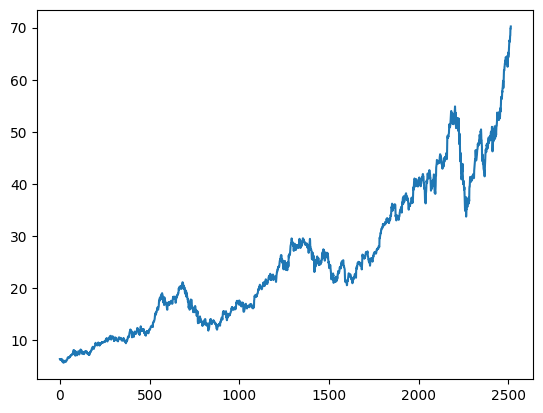

In [35]:
plt.plot(df.Close)

In [36]:
ma100 = df.Close.rolling(100).mean()
ma100


Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,56.912129
2511,57.108721
2512,57.344444
2513,57.571146


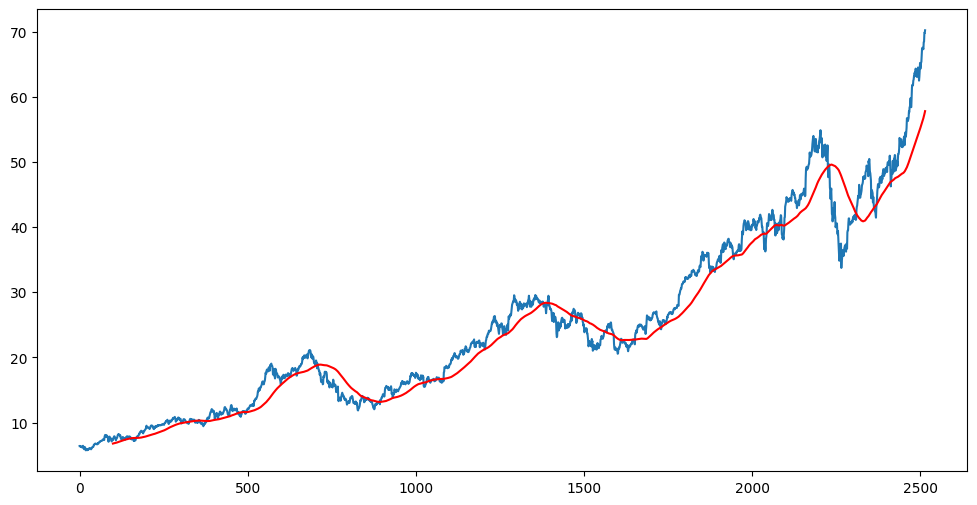

In [37]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')

In [38]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,51.890290
2511,52.017056
2512,52.149660
2513,52.279726


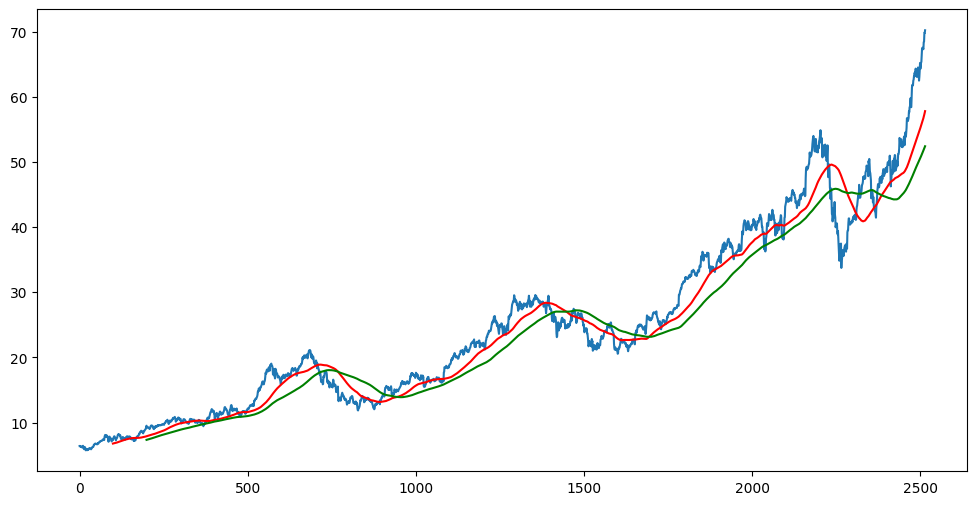

In [39]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')

In [40]:
df.shape

(2515, 5)

In [41]:
df_close = pd.DataFrame(df['Close'].values,
                        index=df.index,
                        columns=['Close'])

In [8]:
# Splitting Data into Training and Testing
data_training=pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing=pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])

print(data_training.shape)
print(data_testing.shape)


(1760, 1)
(755, 1)


In [9]:
data_training.head()


Ticker,AAPL
0,6.406479
1,6.417558
2,6.315477
3,6.303801
4,6.345712


In [10]:
data_testing.head()


Ticker,AAPL
1760,26.854670
1761,26.645315
1762,26.721237
1763,26.691322
1764,26.827066


In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

In [23]:
data_training_array=scaler.fit_transform(data_training)
data_training_array


array([[0.02760001],
       [0.02806513],
       [0.02377929],
       ...,
       [0.884084  ],
       [0.89123182],
       [0.88640214]], shape=(1760, 1))

In [47]:
data_training_array.shape

(1760, 1)

In [48]:
x_train=[]
y_train=[]

for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train , y_train=np.array(x_train), np.array(y_train)

In [49]:
print(x_train.shape)
print(y_train.shape)

(1660, 100, 1)
(1660,)


In [50]:
# ML MODEL

In [51]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [52]:
model=Sequential()
model.add(LSTM(units=50,activation='relu',return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='relu',return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80,activation='relu',return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

C:\Users\salin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 260ms/step - loss: 0.0138
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 368ms/step - loss: 0.0082
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 318ms/step - loss: 0.0087
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - loss: 0.0084
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step - loss: 0.0064
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 201ms/step - loss: 0.0077
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - loss: 0.0060
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - loss: 0.0058
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - loss: 0.0059
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - loss: 0.0058
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - loss: 0.0054
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - loss: 0.0057
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - loss: 0.0056
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 402ms/step - loss: 0.0051
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 39

In [ ]:
model.save('keras_model.keras')

In [11]:
data_testing.head()

Ticker,AAPL
1760,26.854670
1761,26.645315
1762,26.721237
1763,26.691322
1764,26.827066


In [12]:
data_training.tail(100)

Ticker,AAPL
1660,24.804039
1661,24.904745
1662,24.719355
1663,24.703327
1664,24.760546
...,...
1755,26.930586
1756,26.753437
1757,26.806355
1758,26.976603


In [16]:
past_100_days=data_training.tail(100)

In [18]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [19]:
final_df.head()

Ticker,AAPL
0,24.804039
1,24.904745
2,24.719355
3,24.703327
4,24.760546


In [24]:
input_data=scaler.fit_transform(final_df)
input_data

array([[0.02573563],
       [0.02789658],
       [0.02391847],
       [0.02357455],
       [0.02480235],
       [0.03118698],
       [0.03069601],
       [0.02991015],
       [0.02922268],
       [0.0305979 ],
       [0.02642317],
       [0.02809283],
       [0.02406581],
       [0.02180651],
       [0.01871232],
       [0.018123  ],
       [0.01409569],
       [0.01458666],
       [0.01768097],
       [0.02259232],
       [0.02244482],
       [0.02568639],
       [0.01173824],
       [0.        ],
       [0.0113453 ],
       [0.02367282],
       [0.04243417],
       [0.06109741],
       [0.05790504],
       [0.05132391],
       [0.05127484],
       [0.05117645],
       [0.05643163],
       [0.04705096],
       [0.04788589],
       [0.04891719],
       [0.05314103],
       [0.04444802],
       [0.0487209 ],
       [0.04611768],
       [0.04847517],
       [0.0487209 ],
       [0.05284627],
       [0.05368136],
       [0.06345494],
       [0.0646827 ],
       [0.06979066],
       [0.068

In [25]:
input_data.shape

(855, 1)

In [26]:
x_test=[]
y_test=[]

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

In [27]:
x_test,y_test=np.array(x_test),np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(755, 100, 1)
(755,)
